In [17]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [18]:
import pandas as pd
import numpy as np
from preprocessing.preprocessing_utils import preprocess_actuarial

# 1. Load Data
train = pd.read_csv("../data/claims_train.csv")
test  = pd.read_csv("../data/claims_test.csv")

# 2. Preprocess Training Data
# We pass scaler=None so it fits a new scaler
X_tr_df, y_tr_rate, w_tr, scaler_fitted = preprocess_actuarial(train, scaler=None)

# Save the column names from training to ensure Test set matches exactly
train_cols = X_tr_df.columns.tolist()

# 3. Preprocess Test Data
# We pass the fitted scaler and the reference columns
X_te_df, y_te_rate, w_te, _ = preprocess_actuarial(test, scaler=scaler_fitted, ref_columns=train_cols)

# 4. Convert to Numpy Arrays (float32 is best for NNs)
# Neural networks often error out if inputs are float64 vs float32
X_train = X_tr_df.values.astype(np.float32)
y_train = y_tr_rate.values.astype(np.float32).reshape(-1, 1) # NNs often like shape (N, 1) for y
w_train = w_tr.values.astype(np.float32).reshape(-1, 1)

X_test = X_te_df.values.astype(np.float32)
y_test = y_te_rate.values.astype(np.float32).reshape(-1, 1)
w_test = w_te.values.astype(np.float32).reshape(-1, 1)

# 5. Sanity Check
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape:  {X_test.shape}")
assert X_train.shape[1] == X_test.shape[1], "Mismatch in number of input features!"

Train Shape: (541416, 48)
Test Shape:  (135373, 48)


In [19]:
def poisson_deviance(y_true, y_pred, w):
    # 2 * w * (y_true * log(y_true / y_pred) - (y_true - y_pred))
    # simplified for stability:
    # if y_true == 0: 2 * w * y_pred
    # else: 2 * w * (y_true * log(y_true/y_pred) - (y_true - y_pred))
    
    delta = 1e-12
    dev = 2 * w * (y_true * np.log((y_true + delta) / (y_pred + delta)) - (y_true - y_pred))
    return np.sum(dev) / np.sum(w)

In [20]:
import numpy as np
SEED = 7

class NeuralNetPoisson:
    def __init__(self, input_dim, hidden_dims=[64,32],l2_reg=0.01, seed=SEED):
        """
        input_dim: Number of features (41 in your case)
        hidden_dims: List of neurons for hidden layers
        """
        self.l2_reg = l2_reg
        self.params = self._init_params(input_dim, hidden_dims, seed)
        self.architecture = hidden_dims
    
    def _init_params(self, input_dim, hidden_dims, seed):
        np.random.seed(seed)
        params = {}
        layer_dims = [input_dim] + hidden_dims + [1] # +1 for output layer
        
        for i in range(len(layer_dims)-1):
            n_in = layer_dims[i]
            n_out = layer_dims[i+1]
            
            # He Initialization: random normal * sqrt(2/n_in)
            # This keeps variance stable through layers
            W = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
            b = np.zeros((1, n_out))
            
            params[f'W{i+1}'] = W
            params[f'b{i+1}'] = b
            
        return params

    def relu(self, Z):
        return np.maximum(0, Z)

    def forward(self, X):
        """
        Performs forward propagation.
        Returns:
            y_pred: The final rate predictions (exp(Z_last))
            cache: Dictionary storing Z and A values (needed for backprop)
        """
        cache = {}
        A = X
        n_layers = len(self.architecture) + 1
        
        # Loop through hidden layers
        for i in range(1, n_layers):
            W = self.params[f'W{i}']
            b = self.params[f'b{i}']
            
            Z = np.dot(A, W) + b
            A = self.relu(Z) # ReLU activation
            
            cache[f'Z{i}'] = Z
            cache[f'A{i}'] = A
            
        # Output Layer (No ReLU, use Exp for Poisson)
        W_last = self.params[f'W{n_layers}']
        b_last = self.params[f'b{n_layers}']
        
        Z_last = np.dot(A, W_last) + b_last
        
        # Output function: Exponential (ensures rate is positive)
        y_pred = np.exp(Z_last) 
        
        cache[f'Z{n_layers}'] = Z_last
        cache[f'A{n_layers}'] = y_pred
        
        return y_pred, cache
    
    def compute_loss(self, y_true, y_pred, w):
        """
        Weighted Poisson Loss + L2 Regularization Term
        """
        epsilon = 1e-15
        y_pred = np.maximum(y_pred, epsilon)
        N = y_true.shape[0]
        
        # 1. Standard Poisson Loss
        core_loss = np.sum(w * (y_pred - y_true * np.log(y_pred))) / N
        
        # 2. L2 Regularization Penalty (Sum of squared weights)
        # We sum W1, W2, W3... but NOT biases
        l2_cost = 0
        n_layers = len(self.architecture) + 1
        for i in range(1, n_layers + 1):
            W = self.params[f'W{i}']
            l2_cost += np.sum(np.square(W))
            
        # Scale by lambda/2
        reg_loss = (self.l2_reg / 2) * l2_cost
        
        return core_loss + reg_loss

    
    def backward(self, X, y_true, y_pred, w, cache):
        """
        Calculates gradients for all parameters.
        
        Args:
            y_true: Actual Claim Rates
            y_pred: Predicted Claim Rates
            w: Exposure weights
        """
        N = X.shape[0]
        grads = {}
        n_layers = len(self.architecture) + 1
        
        # ----------------------------------------------
        # 1. Gradient at Output Layer
        # dL/dZ_last = (w/N) * (Predicted_Rate - True_Rate)
        # ----------------------------------------------
        dZ = (w / N) * (y_pred - y_true)
        
        # Loop backwards from last layer to first
        for i in range(n_layers, 0, -1):
            # Previous layer activation (if i=1, prev is Input X)
            A_prev = X if i == 1 else cache[f'A{i-1}']
            W = self.params[f'W{i}']
            
            # Gradients for Weights and Biases
            # dW = A_prev.T * dZ
            dW = np.dot(A_prev.T, dZ) + (self.l2_reg * W)
            db = np.sum(dZ, axis=0, keepdims=True)
            
            grads[f'dW{i}'] = dW
            grads[f'db{i}'] = db
            
            # ----------------------------------------------
            # 2. Propagate error to previous layer (if not at input)
            # ----------------------------------------------
            if i > 1:
                dA = np.dot(dZ, W.T)
                
                # Derivative of ReLU: 1 if Z>0, else 0
                Z_prev = cache[f'Z{i-1}']
                dZ = dA * (Z_prev > 0) 
        return grads

    def update_params_with_momentum(self, grads, learning_rate=0.001, beta=0.9):
        """
        Updates parameters using SGD with Momentum.
        beta: Momentum hyperparameter (0.9 is standard)
        """
        n_layers = len(self.architecture) + 1
        
        # Initialize velocity if it doesn't exist yet
        if not hasattr(self, 'velocity') or len(self.velocity) == 0:
            self.velocity = {}
            for i in range(1, n_layers + 1):
                self.velocity[f'W{i}'] = np.zeros_like(self.params[f'W{i}'])
                self.velocity[f'b{i}'] = np.zeros_like(self.params[f'b{i}'])
        
        for i in range(1, n_layers + 1):
            # 1. Calculate new velocity
            # v = beta * v_old + (1 - beta) * gradient
            self.velocity[f'W{i}'] = beta * self.velocity[f'W{i}'] + (1 - beta) * grads[f'dW{i}']
            self.velocity[f'b{i}'] = beta * self.velocity[f'b{i}'] + (1 - beta) * grads[f'db{i}']
            
            # 2. Update parameters using velocity
            self.params[f'W{i}'] -= learning_rate * self.velocity[f'W{i}']
            self.params[f'b{i}'] -= learning_rate * self.velocity[f'b{i}']

--- Fair Architecture Search: Decoupling Error from Penalty ---
Testing CurrentBest [256, 128, 64]... Deviance=0.6306 | Penalty=3.8376
Testing Wide [512, 256, 128]... Deviance=0.6282 | Penalty=7.6507
Testing Deep [256, 128, 64, 32]... Deviance=0.6338 | Penalty=4.1194


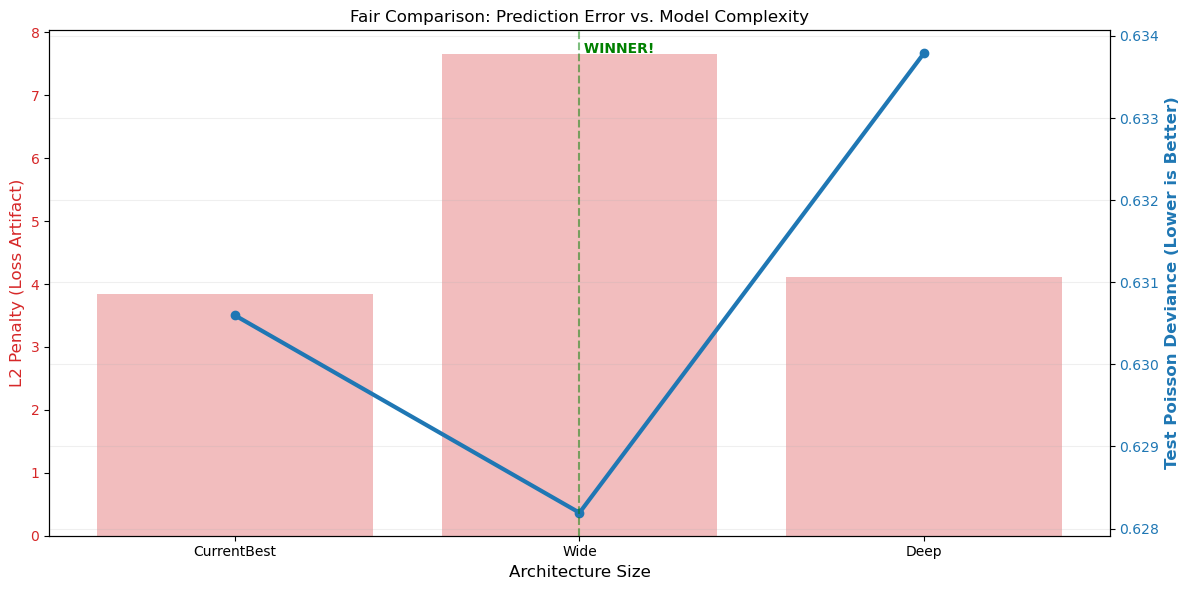

In [22]:
import matplotlib.pyplot as plt
import numpy as np

RUN_EXPERIEMENTS = True
# 1. Define the Grid
configs = [
    #{'name': 'Tiny',       'dims': [8, 4]},
    #{'name': 'Small',      'dims': [16, 8]},
    #{'name': 'Medium',     'dims': [32, 16]},
    #{'name': 'Large',      'dims': [64, 32]},
    #{'name': 'XLarge',     'dims': [128, 64]},
    #{'name': 'XXLarge',    'dims': [128, 64, 32]},
    # Keep the current winner as a baseline
    {'name': 'CurrentBest', 'dims': [256, 128, 64]},
    
    # Strategy 1: Go Wider (More capacity in existing layers)
    {'name': 'Wide',        'dims': [512, 256, 128]},
    
    # Strategy 2: Go Deeper (Add a 4th layer - might be hard to train)
    {'name': 'Deep',        'dims': [256, 128, 64, 32]},
    
    # Strategy 3: Massive (Wide + Deep)
    #{'name': 'Massive',     'dims': [512, 256, 128, 64]}
]
if RUN_EXPERIEMENTS:

    names = []
    deviance_scores = []  # The "Fitness" (Lower is better)
    l2_costs = []         # The "Tax" (Higher for bigger models)

    print(f"--- Fair Architecture Search: Decoupling Error from Penalty ---")

    for conf in configs:
        print(f"Testing {conf['name']} {conf['dims']}...", end=" ")
        
        # Initialize FRESH model
        model = NeuralNetPoisson(
            input_dim=X_train.shape[1], 
            hidden_dims=conf['dims'], 
            l2_reg=0.01,  # Keep constant for fair comparison
            seed=42
        )
        
        # Train (Fast 30 epochs is enough to see the trend)
        for epoch in range(30):
            indices = np.arange(X_train.shape[0])
            np.random.shuffle(indices)
            for start_idx in range(0, X_train.shape[0], 1024):
                end_idx = min(start_idx + 1024, X_train.shape[0])
                idx = indices[start_idx:end_idx]
                
                # Forward / Backward
                y_p, cache = model.forward(X_train[idx])
                grads = model.backward(X_train[idx], y_train[idx], y_p, w_train[idx], cache)
                
                # Update with MOMENTUM
                model.update_params_with_momentum(grads, learning_rate=0.0005)

        # 1. Calculate Poisson Deviance (The Real Performance Metric)
        y_pred_val, _ = model.forward(X_test)
        dev = poisson_deviance(y_test, y_pred_val, w_test)
        
        # 2. Calculate L2 Cost Explicitly (The Penalty "Tax")
        # Sum of squared weights * (lambda / 2)
        l2_sum = 0
        n_layers = len(model.architecture) + 1
        for i in range(1, n_layers + 1):
            W = model.params[f'W{i}']
            l2_sum += np.sum(np.square(W))
        l2_cost = (model.l2_reg / 2) * l2_sum
        
        names.append(conf['name'])
        deviance_scores.append(dev)
        l2_costs.append(l2_cost)
        
        print(f"Deviance={dev:.4f} | Penalty={l2_cost:.4f}")

    # --- VISUALIZATION ---
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot 1: L2 Penalty (Bars) - The "Cost" of being big
    color = 'tab:red'
    ax1.set_xlabel('Architecture Size', fontsize=12)
    ax1.set_ylabel('L2 Penalty (Loss Artifact)', color=color, fontsize=12)
    bars = ax1.bar(names, l2_costs, color=color, alpha=0.3, label='L2 Penalty Cost')
    ax1.tick_params(axis='y', labelcolor=color)

    # Plot 2: Poisson Deviance (Line) - The "True Performance"
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Test Poisson Deviance (Lower is Better)', color=color, fontsize=12, weight='bold')
    line = ax2.plot(names, deviance_scores, color=color, marker='o', linewidth=3, label='Poisson Deviance')
    ax2.tick_params(axis='y', labelcolor=color)

    # Add visual guide for the "Winner"
    best_idx = np.argmin(deviance_scores)
    ax2.axvline(best_idx, color='green', linestyle='--', alpha=0.5)
    plt.text(best_idx, max(deviance_scores), " WINNER!", color='green', fontweight='bold', ha='left')

    plt.title('Fair Comparison: Prediction Error vs. Model Complexity')
    plt.grid(True, alpha=0.2)
    fig.tight_layout()
    plt.show()

--- Fast Tuning on 162424 samples (30.0%) ---
Testing Lambda=0.0... Deviance=0.63600
Testing Lambda=0.0001... Deviance=0.63600
Testing Lambda=0.001... Deviance=0.63604
Testing Lambda=0.005... Deviance=0.63623
Testing Lambda=0.01... Deviance=0.63654
Testing Lambda=0.05... Deviance=0.64294
Testing Lambda=0.1... Deviance=0.66401


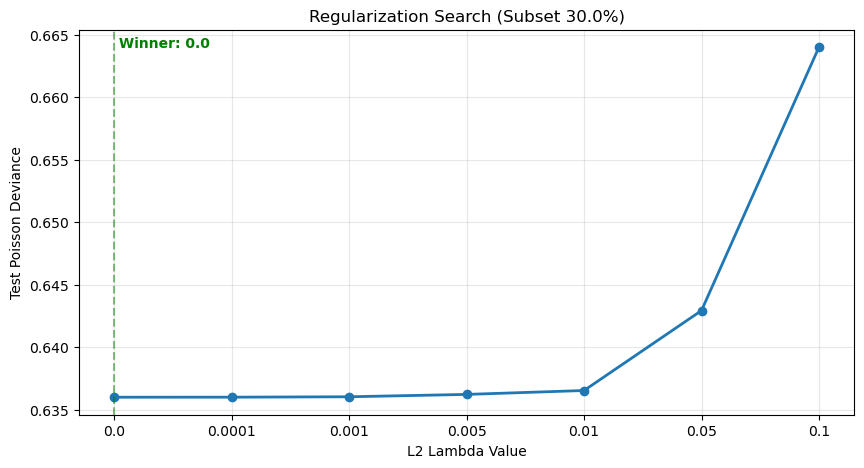

Best Lambda: 0.0


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- SPEED CONFIGURATION ---
TUNING_PCT = 0.30      # Use only 30% of data for tuning (Massive speedup)
TUNING_BATCH = 4096    # Larger batch size = fewer loop iterations = faster
TUNING_EPOCHS = 10     # 10 epochs is enough to differentiate lambdas

# 1. Create a fixed subset for fair comparison
# We do this ONCE so all lambdas see the exact same random subset
N_subset = int(X_train.shape[0] * TUNING_PCT)
np.random.seed(7) # Ensure reproducibility
subset_idx = np.random.choice(X_train.shape[0], N_subset, replace=False)

X_tune = X_train[subset_idx]
y_tune = y_train[subset_idx]
w_tune = w_train[subset_idx]

print(f"--- Fast Tuning on {N_subset} samples ({TUNING_PCT*100}%) ---")

# 2. Define the Lambdas
lambdas = [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.1]
BEST_DIMS = [512, 256, 128] 

results_reg = []
reg_names = []

for lam in lambdas:
    print(f"Testing Lambda={lam}...", end=" ")
    
    # Initialize Model
    model = NeuralNetPoisson(
        input_dim=X_tune.shape[1], 
        hidden_dims=BEST_DIMS, 
        l2_reg=lam, 
        seed=7
    )
    
    # Train (Faster loop)
    for epoch in range(TUNING_EPOCHS):
        indices = np.arange(X_tune.shape[0])
        np.random.shuffle(indices)
        
        # Larger batch step
        for start_idx in range(0, X_tune.shape[0], TUNING_BATCH):
            end_idx = min(start_idx + TUNING_BATCH, X_tune.shape[0])
            idx = indices[start_idx:end_idx]
            
            y_p, cache = model.forward(X_tune[idx])
            grads = model.backward(X_tune[idx], y_tune[idx], y_p, w_tune[idx], cache)
            model.update_params_with_momentum(grads, learning_rate=0.01)
            
    # Evaluate on FULL Test Set 
    # (Prediction is fast, so use the full test set for accuracy)
    y_pred_val, _ = model.forward(X_test)
    dev = poisson_deviance(y_test, y_pred_val, w_test)
    
    print(f"Deviance={dev:.5f}")
    results_reg.append(dev)
    reg_names.append(str(lam))

# --- VISUALIZATION ---
plt.figure(figsize=(10, 5))
plt.plot(reg_names, results_reg, marker='o', linestyle='-', linewidth=2)
best_idx = np.argmin(results_reg)
plt.axvline(best_idx, color='green', linestyle='--', alpha=0.5)
plt.text(best_idx, max(results_reg), f" Winner: {reg_names[best_idx]}", color='green', fontweight='bold')
plt.title(f"Regularization Search (Subset {TUNING_PCT*100}%)")
plt.xlabel("L2 Lambda Value")
plt.ylabel("Test Poisson Deviance")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best Lambda: {lambdas[best_idx]}")

Training Final Neural Network (Wide, No L2)...
Epoch 0: Train=0.24216, Val=0.19918
Epoch 1: Train=0.19113, Val=0.18809
Epoch 2: Train=0.18538, Val=0.18514
Epoch 3: Train=0.18325, Val=0.18353
Epoch 4: Train=0.18190, Val=0.18233
Epoch 5: Train=0.18084, Val=0.18135
Epoch 6: Train=0.18000, Val=0.18054
Epoch 7: Train=0.17928, Val=0.17985
Epoch 8: Train=0.17867, Val=0.17926
Epoch 9: Train=0.17816, Val=0.17876
Epoch 10: Train=0.17771, Val=0.17833
Epoch 11: Train=0.17732, Val=0.17795
Epoch 12: Train=0.17696, Val=0.17761
Epoch 13: Train=0.17666, Val=0.17731
Epoch 14: Train=0.17640, Val=0.17704
Epoch 15: Train=0.17613, Val=0.17679
Epoch 16: Train=0.17589, Val=0.17656
Epoch 17: Train=0.17570, Val=0.17634
Epoch 18: Train=0.17549, Val=0.17614
Epoch 19: Train=0.17530, Val=0.17595
Epoch 20: Train=0.17514, Val=0.17577
Epoch 21: Train=0.17494, Val=0.17560
Epoch 22: Train=0.17478, Val=0.17543
Epoch 23: Train=0.17462, Val=0.17527
Epoch 24: Train=0.17448, Val=0.17512
Epoch 25: Train=0.17433, Val=0.17498
E

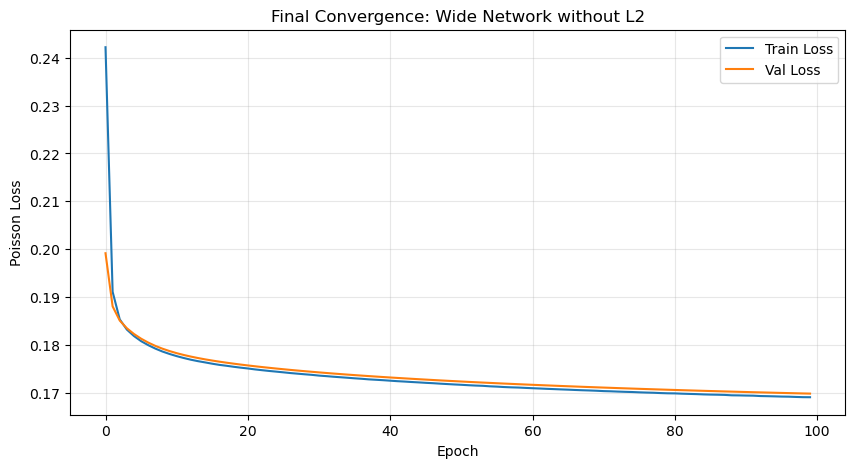

In [24]:
# ==========================================
# FINAL METHOD 2 MODEL (Optimized)
# ==========================================

# 1. Configure the Winner
# Architecture: Wide [512, 256, 128]
# Regularization: 0.0 (Data volume + Early Stopping is enough)
nn = NeuralNetPoisson(
    input_dim=X_train.shape[1], 
    hidden_dims=[512, 256, 128], 
    l2_reg=0.0,   # <--- Updated based on your search
    seed=42
)

# 2. Train on FULL Data (Not just the 30% subset)
EPOCHS = 100
BATCH_SIZE = 1024
LR = 0.0005
PATIENCE = 5

train_loss_history = []
val_loss_history = []
best_val_loss = np.inf
patience_counter = 0

print(f"Training Final Neural Network (Wide, No L2)...")

for epoch in range(EPOCHS):
    indices = np.arange(X_train.shape[0])
    np.random.shuffle(indices)
    
    epoch_loss = 0
    num_batches = 0
    
    for start_idx in range(0, X_train.shape[0], BATCH_SIZE):
        end_idx = min(start_idx + BATCH_SIZE, X_train.shape[0])
        idx = indices[start_idx:end_idx]
        X_batch, y_batch, w_batch = X_train[idx], y_train[idx], w_train[idx]
        
        y_pred, cache = nn.forward(X_batch)
        # Note: compute_loss will essentially be just Poisson now since L2=0
        loss = nn.compute_loss(y_batch, y_pred, w_batch)
        epoch_loss += loss
        num_batches += 1
        
        grads = nn.backward(X_batch, y_batch, y_pred, w_batch, cache)
        nn.update_params_with_momentum(grads, learning_rate=LR)
    
    avg_train_loss = epoch_loss / num_batches
    train_loss_history.append(avg_train_loss)

    # Validation
    y_pred_val, _ = nn.forward(X_test)
    val_loss = nn.compute_loss(y_test, y_pred_val, w_test)
    val_loss_history.append(val_loss)
    
    print(f"Epoch {epoch}: Train={avg_train_loss:.5f}, Val={val_loss:.5f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# 3. Final Metrics
print("\n=== FINAL NEURAL NETWORK RESULTS ===")
y_pred_final, _ = nn.forward(X_test)
final_dev = poisson_deviance(y_test, y_pred_final, w_test)
print(f"Final Test Deviance: {final_dev:.5f}")

# 4. Plot Learning Curve (For Report)
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title("Final Convergence: Wide Network without L2")
plt.xlabel("Epoch")
plt.ylabel("Poisson Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
# 1. Predict on Test Data
y_pred_test, _ = nn.forward(X_test)



# 2. Calculate Metrics
final_train_loss = train_loss_history[-1]
test_deviance = poisson_deviance(y_test, y_pred_test, w_test)

print(f"Final Training Loss: {final_train_loss:.5f}")
print(f"Test Set Poisson Deviance: {test_deviance:.5f}")

# Optional: Mean Absolute Error (Rate)
mae = np.average(np.abs(y_test - y_pred_test).flatten(), weights=w_test.flatten())
print(f"Test Set Weighted MAE: {mae:.5f}")

Final Training Loss: 0.16914
Test Set Poisson Deviance: 0.60890
Test Set Weighted MAE: 0.18983


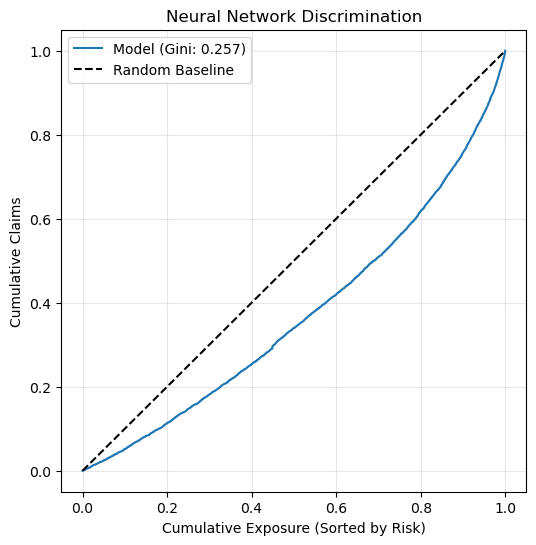

Gini Coefficient: 0.257


In [30]:
def plot_lorenz_curve(y_true, y_pred, w_exposure, title="Lorenz Curve"):
    """
    Plots the Ordered Lorenz Curve for Insurance.
    """
    # 1. Stack data and Sort by Predicted Risk (low to high)
    data = pd.DataFrame({
        'True': y_true.flatten(),
        'Pred': y_pred.flatten(),
        'Weight': w_exposure.flatten()
    })
    data = data.sort_values('Pred')
    
    # 2. Calculate Cumulative Distributions
    data['CumExposure'] = data['Weight'].cumsum() / data['Weight'].sum()
    data['CumClaims'] = (data['True'] * data['Weight']).cumsum() / (data['True'] * data['Weight']).sum()
    
    # 3. Calculate Gini (Area between curve and diagonal)
    # Trapezoidal rule for area under curve
    auc = np.trapz(data['CumClaims'], data['CumExposure'])
    gini = 1 - 2 * auc
    
    # 4. Plot
    plt.figure(figsize=(6, 6))
    plt.plot(data['CumExposure'], data['CumClaims'], label=f'Model (Gini: {gini:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
    plt.title(title)
    plt.xlabel('Cumulative Exposure (Sorted by Risk)')
    plt.ylabel('Cumulative Claims')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return gini

# Run it on your Test Set
gini_score = plot_lorenz_curve(y_test, y_pred_test, w_test, title="Neural Network Discrimination")
print(f"Gini Coefficient: {gini_score:.3f}")

C:\Users\Emil\AppData\Local\Temp\ipykernel_9592\700633636.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby('Bin', observed=False).apply(


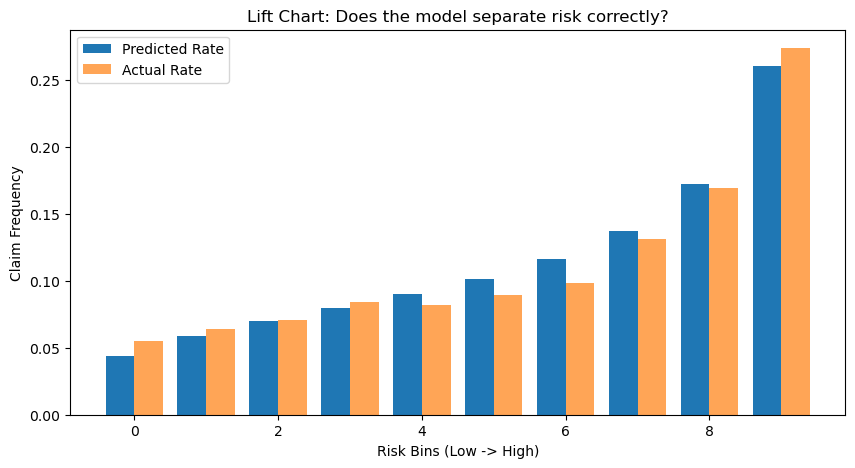

In [31]:
def plot_lift_chart(y_true, y_pred, w, n_bins=10):
    df = pd.DataFrame({'True': y_true.flatten(), 'Pred': y_pred.flatten(), 'Weight': w.flatten()})
    
    # Sort by predicted risk and bin
    df['Bin'] = pd.qcut(df['Pred'], n_bins, duplicates='drop')
    
    # Calculate average predicted vs actual rate per bin
    grouped = df.groupby('Bin', observed=False).apply(
        lambda x: pd.Series({
            'Avg_Pred': np.average(x['Pred'], weights=x['Weight']),
            'Avg_True': np.average(x['True'], weights=x['Weight'])
        })
    )
    
    # Plot
    x = np.arange(len(grouped))
    plt.figure(figsize=(10, 5))
    plt.bar(x - 0.2, grouped['Avg_Pred'], 0.4, label='Predicted Rate')
    plt.bar(x + 0.2, grouped['Avg_True'], 0.4, label='Actual Rate', alpha=0.7)
    plt.xlabel('Risk Bins (Low -> High)')
    plt.ylabel('Claim Frequency')
    plt.title('Lift Chart: Does the model separate risk correctly?')
    plt.legend()
    plt.show()

plot_lift_chart(y_test, y_pred_test, w_test)